--- RISULTATI ANALITICI MANOVRA ---
Angolo di cambio piano spaziale (Theta): 48.422 deg
Posizione nodo di manovra (u1): 6.638 deg
Costo propulsivo Delta-V: 6.15 km/s

--- STATO OREKIT INIZIALIZZATO ---
Orbita pronta per la propagazione.
Semiasse maggiore: 7087.14 km
Inclinazione iniziale: 50.00 deg


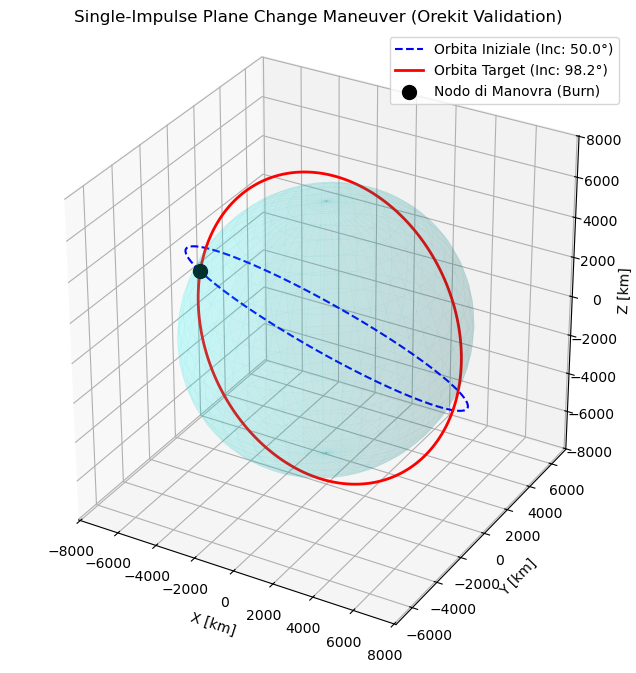

In [6]:
import numpy as np
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import AbsoluteDate, TimeScalesFactory
from org.orekit.utils import Constants

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

# ==========================================
# 2. COSTANTI INDUSTRIALI
# ==========================================
mu = Constants.WGS84_EARTH_MU
R_Earth = Constants.WGS84_EARTH_EQUATORIAL_RADIUS

# ==========================================
# 3. CINEMATICA E GEOMETRIA DELLA MANOVRA (Logica MATLAB)
# ==========================================
h = 709000.0  # Quota in metri (709 km)
a = R_Earth + h # Semiasse maggiore in metri
Vc = np.sqrt(mu / a) # Velocità circolare in m/s

# Parametri orbita iniziale
inc1 = np.radians(50.0)
RAAN1 = np.radians(170.0)

# Parametri orbita target (es. eliosincrona)
inc2 = np.radians(98.2)
RAAN2 = np.radians(175.012)
DeltaOmega = RAAN2 - RAAN1

# Legge dei coseni per triangoli sferici: Angolo spaziale totale (theta)
theta = np.arccos(np.cos(inc1)*np.cos(inc2) + np.sin(inc1)*np.sin(inc2)*np.cos(DeltaOmega))

# Argomento di latitudine del nodo di manovra (u1)
u1 = np.arccos((-np.cos(inc2) + np.cos(theta)*np.cos(inc1)) / (np.sin(theta)*np.sin(inc1)))

# Costo propulsivo totale per il cambio piano puro
delta_v = 2 * Vc * np.sin(theta / 2)

print("--- RISULTATI ANALITICI MANOVRA ---")
print(f"Angolo di cambio piano spaziale (Theta): {np.degrees(theta):.3f} deg")
print(f"Posizione nodo di manovra (u1): {np.degrees(u1):.3f} deg")
print(f"Costo propulsivo Delta-V: {delta_v/1000:.2f} km/s")

# ==========================================
# 4. CREAZIONE DELL'OGGETTO ORBITA (Motore Orekit)
# ==========================================
inertial_frame = FramesFactory.getEME2000()
utc = TimeScalesFactory.getUTC()
# Data arbitraria di inizio simulazione
initial_date = AbsoluteDate(2026, 6, 18, 12, 0, 0.0, utc) 

# Parametri Kepleriani per Orekit
e = 0.0
omega = 0.0 # Essendo circolare, fissiamo convenzionalmente l'argomento del perigeo a 0

# Inseriamo u1 come Anomalia Vera (True Anomaly)
# Convertiamo esplicitamente tutti i parametri in float standard per evitare conflitti con Java
initial_orbit = KeplerianOrbit(
    float(a), 
    float(e), 
    float(inc1), 
    float(omega), 
    float(RAAN1), 
    float(u1), 
    PositionAngleType.TRUE, 
    inertial_frame, 
    initial_date, 
    float(mu)
)

print("\n--- STATO OREKIT INIZIALIZZATO ---")
print(f"Orbita pronta per la propagazione.")
print(f"Semiasse maggiore: {initial_orbit.getA() / 1000.0:.2f} km")
print(f"Inclinazione iniziale: {np.degrees(initial_orbit.getI()):.2f} deg")
import matplotlib.pyplot as plt
import numpy as np
from org.orekit.orbits import KeplerianOrbit, PositionAngleType

# ==========================================
# 5. VISUALIZZAZIONE 3D DELLA MANOVRA
# ==========================================

# Creiamo l'orbita target per il plot (stesso a, stesso e, ma nuova inc e RAAN)
final_orbit = KeplerianOrbit(
    float(a), float(e), float(inc2), float(omega), float(RAAN2), float(u1), 
    PositionAngleType.TRUE, inertial_frame, initial_date, float(mu)
)

# Periodo orbitale in secondi (circa 6000 secondi per LEO)
T = initial_orbit.getKeplerianPeriod()

# Campionamento di 200 punti lungo un'orbita completa
time_steps = np.linspace(0, T, 200)

x1, y1, z1 = [], [], []
x2, y2, z2 = [], [], []

# Estrazione delle coordinate X,Y,Z nel tempo
for dt in time_steps:
    # Propaga e ottieni la posizione per l'orbita 1
    pos1 = initial_orbit.shiftedBy(float(dt)).getPVCoordinates().getPosition()
    x1.append(pos1.getX() / 1000)
    y1.append(pos1.getY() / 1000)
    z1.append(pos1.getZ() / 1000)
    
    # Propaga e ottieni la posizione per l'orbita 2
    pos2 = final_orbit.shiftedBy(float(dt)).getPVCoordinates().getPosition()
    x2.append(pos2.getX() / 1000)
    y2.append(pos2.getY() / 1000)
    z2.append(pos2.getZ() / 1000)

# Posizione esatta del nodo di manovra (all'istante t=0)
maneuver_pos = initial_orbit.getPVCoordinates().getPosition()
mx = maneuver_pos.getX() / 1000
my = maneuver_pos.getY() / 1000
mz = maneuver_pos.getZ() / 1000

# Creazione del Plot 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Disegno della Terra (Sfera semi-trasparente)
u_sphere, v_sphere = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
R_e_km = R_Earth / 1000
x_e = R_e_km * np.cos(u_sphere) * np.sin(v_sphere)
y_e = R_e_km * np.sin(u_sphere) * np.sin(v_sphere)
z_e = R_e_km * np.cos(v_sphere)
ax.plot_surface(x_e, y_e, z_e, color='cyan', alpha=0.1, edgecolor='c', linewidth=0.1)

# Disegno delle Orbite
ax.plot(x1, y1, z1, label=f'Orbita Iniziale (Inc: {np.degrees(inc1):.1f}°)', color='blue', linestyle='--')
ax.plot(x2, y2, z2, label=f'Orbita Target (Inc: {np.degrees(inc2):.1f}°)', color='red', linewidth=2)

# Evidenziamo il Nodo di Manovra
ax.scatter([mx], [my], [mz], color='black', s=100, label='Nodo di Manovra (Burn)', zorder=5)

# Setup della vista grafica
ax.set_box_aspect([1,1,1]) # Mantiene le proporzioni 1:1:1 per non deformare l'orbita
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_zlabel('Z [km]')
ax.set_title('Single-Impulse Plane Change Maneuver (Orekit Validation)')
ax.legend()

plt.show()
# Setup della vista grafica
ax.set_box_aspect([1,1,1]) 
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_zlabel('Z [km]')
ax.set_title('Single-Impulse Plane Change Maneuver (Orekit Validation)')
ax.legend()

# 1. SALVA usando l'oggetto 'fig' in modo esplicito
fig.savefig('single_impulse_plot.png', dpi=300, bbox_inches='tight', facecolor='white')

# 2. MOSTRA il grafico (deve essere rigorosamente l'ultimo comando)
plt.show()